<a href="https://colab.research.google.com/github/oguilherme-barreto/Calculo_Numerico/blob/main/atividade_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display



# Parâmetros gerais da atividade


In [13]:
TOL = 1e-6
MAX_ITER = 100
EPS = 1e-14

## 1. Funções estudadas

As quatro funções fornecidas no enunciado são:

\[
f_1(x)=x^2-2
\]

\[
f_2(x)=x^3-x-2
\]

\[
f_3(x)=e^{-x}-x
\]

\[
f_4(x)=x^3-2x+2
\]

Os intervalos e valores iniciais abaixo seguem a tabela de sugestões do enunciado.

In [2]:
# Funções e derivadas
def f1(x):
    return x**2 - 2

def df1(x):
    return 2*x


def f2(x):
    return x**3 - x - 2

def df2(x):
    return 3*x**2 - 1


def f3(x):
    return math.exp(-x) - x

def df3(x):
    return -math.exp(-x) - 1


def f4(x):
    return x**3 - 2*x + 2

def df4(x):
    return 3*x**2 - 2


funcoes = {
    "f1(x) = x² - 2": {
        "f": f1, "df": df1,
        "intervalo": (1, 2),
        "x0": 1.5,
        "secante": (1, 2)
    },
    "f2(x) = x³ - x - 2": {
        "f": f2, "df": df2,
        "intervalo": (1, 2),
        "x0": 1.5,
        "secante": (1, 2)
    },
    "f3(x) = e⁻ˣ - x": {
        "f": f3, "df": df3,
        "intervalo": (0, 1),
        "x0": 0.5,
        "secante": (0, 1)
    },
    "f4(x) = x³ - 2x + 2": {
        "f": f4, "df": df4,
        "intervalo": (-2, -1),
        "x0": -2,
        "secante": (-2, -1)
    }
}

## 2. Método da bisseção

In [3]:
def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    """Método da bisseção.

    Retorna:
        raiz: aproximação final
        iteracoes: número de iterações realizadas
        aproximacoes: pontos médios calculados
        convergiu: True/False
        historico: dados usados pela animação
    """

    fa = f(a)
    fb = f(b)

    # Verificação da condição necessária para a bisseção
    if fa * fb > 0:
        return None, 0, [], False, []

    aproximacoes = []
    historico = []
    anterior = None

    for k in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)

        aproximacoes.append(c)

        dx = abs(c - anterior) if anterior is not None else np.inf

        historico.append({
            "iteracao": k,
            "a": a,
            "b": b,
            "c": c,
            "fc": fc
        })

        # Critério de parada:
        # diferença entre aproximações + resíduo
        if anterior is not None:
            if dx < tol and abs(fc) < tol:
                return c, k, aproximacoes, True, historico
        elif abs(fc) < tol:
            return c, k, aproximacoes, True, historico

        # Atualização do intervalo
        if fa * fc < 0:
            b = c
            fb = fc
        elif fc * fb < 0:
            a = c
            fa = fc
        else:
            # fc == 0: raiz exata
            return c, k, aproximacoes, True, historico

        anterior = c

    return c, max_iter, aproximacoes, False, historico

## 3. Método de Newton

In [4]:
def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER):
    """Método de Newton-Raphson."""

    aproximacoes = [x0]
    historico = [{
        "iteracao": 0,
        "x": x0,
        "fx": f(x0),
        "derivada": df(x0)
    }]

    x = x0

    for k in range(1, max_iter + 1):
        dfx = df(x)

        # Evita divisão por uma derivada nula ou quase nula
        if abs(dfx) < EPS:
            return x, k - 1, aproximacoes, False, historico

        x_novo = x - f(x) / dfx
        fx_novo = f(x_novo)

        aproximacoes.append(x_novo)

        historico.append({
            "iteracao": k,
            "x": x_novo,
            "fx": fx_novo,
            "derivada": df(x_novo),
            "x_anterior": x
        })

        if abs(x_novo - x) < tol and abs(fx_novo) < tol:
            return x_novo, k, aproximacoes, True, historico

        x = x_novo

    return x, max_iter, aproximacoes, False, historico

## 4. Método da secante

In [5]:
def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER):
    """Método da secante."""

    aproximacoes = [x0, x1]

    historico = [{
        "iteracao": 0,
        "x0": x0,
        "x1": x1,
        "x": x1,
        "fx": f(x1)
    }]

    for k in range(1, max_iter + 1):
        f0 = f(x0)
        f1 = f(x1)

        denominador = f1 - f0

        # Evita divisão por número nulo ou muito pequeno
        if abs(denominador) < EPS:
            return x1, k - 1, aproximacoes, False, historico

        x2 = x1 - f1 * (x1 - x0) / denominador
        f2 = f(x2)

        aproximacoes.append(x2)

        historico.append({
            "iteracao": k,
            "x0": x0,
            "x1": x1,
            "x": x2,
            "fx": f2
        })

        if abs(x2 - x1) < tol and abs(f2) < tol:
            return x2, k, aproximacoes, True, historico

        x0, x1 = x1, x2

    return x1, max_iter, aproximacoes, False, historico

## 5. Teste das quatro funções

In [6]:
resultados = []

for nome, dados in funcoes.items():
    f = dados["f"]
    df = dados["df"]

    # Bisseção
    a, b = dados["intervalo"]
    raiz, it, aprox, ok, hist = bissecao(f, a, b)

    resultados.append({
        "Função": nome,
        "Método": "Bisseção",
        "Valores iniciais": f"[{a}, {b}]",
        "Raiz aproximada": raiz,
        "|f(x)| final": abs(f(raiz)) if raiz is not None else np.nan,
        "Iterações": it,
        "Resultado": "Convergiu" if ok else "Falhou"
    })

    # Newton
    x0 = dados["x0"]
    raiz, it, aprox, ok, hist = newton(f, df, x0)

    resultados.append({
        "Função": nome,
        "Método": "Newton",
        "Valores iniciais": f"x0 = {x0}",
        "Raiz aproximada": raiz,
        "|f(x)| final": abs(f(raiz)) if raiz is not None else np.nan,
        "Iterações": it,
        "Resultado": "Convergiu" if ok else "Falhou"
    })

    # Secante
    x0, x1 = dados["secante"]
    raiz, it, aprox, ok, hist = secante(f, x0, x1)

    resultados.append({
        "Função": nome,
        "Método": "Secante",
        "Valores iniciais": f"({x0}, {x1})",
        "Raiz aproximada": raiz,
        "|f(x)| final": abs(f(raiz)) if raiz is not None else np.nan,
        "Iterações": it,
        "Resultado": "Convergiu" if ok else "Falhou"
    })

tabela_resultados = pd.DataFrame(resultados)

# Formatação para apresentação
tabela_resultados["Raiz aproximada"] = tabela_resultados["Raiz aproximada"].map(
    lambda x: f"{x:.10f}" if pd.notna(x) else "—"
)

tabela_resultados["|f(x)| final"] = tabela_resultados["|f(x)| final"].map(
    lambda x: f"{x:.3e}" if pd.notna(x) else "—"
)

tabela_resultados

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações,Resultado
0,f1(x) = x² - 2,Bisseção,"[1, 2]",1.4142136574,2.687e-07,21,Convergiu
1,f1(x) = x² - 2,Newton,x0 = 1.5,1.4142135624,4.441e-16,4,Convergiu
2,f1(x) = x² - 2,Secante,"(1, 2)",1.4142135624,8.882e-16,6,Convergiu
3,f2(x) = x³ - x - 2,Bisseção,"[1, 2]",1.5213797092,1.450e-08,22,Convergiu
4,f2(x) = x³ - x - 2,Newton,x0 = 1.5,1.5213797068,4.530e-14,3,Convergiu
5,f2(x) = x³ - x - 2,Secante,"(1, 2)",1.5213797068,1.843e-14,7,Convergiu
6,f3(x) = e⁻ˣ - x,Bisseção,"[0, 1]",0.5671434402,2.348e-07,20,Convergiu
7,f3(x) = e⁻ˣ - x,Newton,x0 = 0.5,0.5671432904,4.441e-15,3,Convergiu
8,f3(x) = e⁻ˣ - x,Secante,"(0, 1)",0.5671432904,1.242e-13,5,Convergiu
9,f4(x) = x³ - 2x + 2,Bisseção,"[-2, -1]",-1.7692923546,2.551e-09,21,Convergiu


## 6. Verificação individual das iterações

A célula abaixo permite consultar o histórico de qualquer combinação de função e método.

In [7]:
def executar_teste(nome_funcao, metodo):
    dados = funcoes[nome_funcao]
    f = dados["f"]
    df = dados["df"]

    if metodo.lower() == "bissecao":
        raiz, it, aprox, ok, hist = bissecao(f, *dados["intervalo"])
    elif metodo.lower() == "newton":
        raiz, it, aprox, ok, hist = newton(f, df, dados["x0"])
    elif metodo.lower() == "secante":
        raiz, it, aprox, ok, hist = secante(f, *dados["secante"])
    else:
        raise ValueError("Método deve ser: bissecao, newton ou secante.")

    print("Função:", nome_funcao)
    print("Método:", metodo)
    print(f"Raiz aproximada: {raiz:.12f}")
    print(f"|f(x)|: {abs(f(raiz)):.3e}")
    print("Iterações:", it)
    print("Convergiu:", ok)

    return pd.DataFrame(hist)


# Exemplo:
historico_exemplo = executar_teste("f1(x) = x² - 2", "newton")
historico_exemplo

Função: f1(x) = x² - 2
Método: newton
Raiz aproximada: 1.414213562373
|f(x)|: 4.441e-16
Iterações: 4
Convergiu: True


,iteracao,x,fx,derivada,x_anterior
0,0,1.500000,2.500000e-01,3.000000,NaN
1,1,1.416667,6.944444e-03,2.833333,1.500000
2,2,1.414216,6.007305e-06,2.828431,1.416667
3,3,1.414214,4.510614e-12,2.828427,1.414216
4,4,1.414214,4.440892e-16,2.828427,1.414214


## 7. Animação — Bisseção

A animação mostra:
- a função e o eixo \(y=0\);
- o intervalo atual \([a,b]\);
- o ponto médio \(c\);
- o número da iteração;
- o valor da aproximação;
- o resíduo \(|f(c)|\).

GIF salvo em: 01_bissecao_f1.gif
Convergiu: True | Iterações: 21


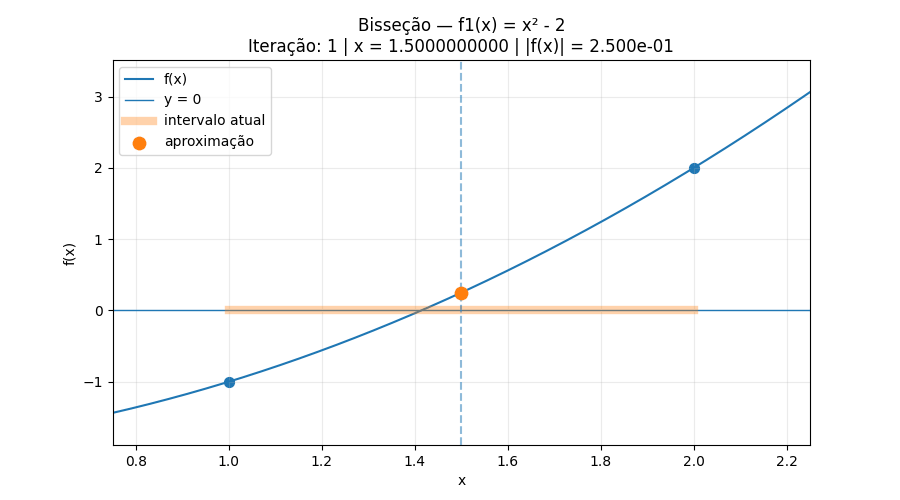

In [8]:
def animar_bissecao(nome_funcao, arquivo="bissecao.gif", intervalo_grafico=None):
    dados = funcoes[nome_funcao]
    f = dados["f"]
    a, b = dados["intervalo"]

    raiz, it, aprox, ok, hist = bissecao(f, a, b)

    if intervalo_grafico is None:
        margem = 0.25 * max(1, abs(b - a))
        xmin = a - margem
        xmax = b + margem
    else:
        xmin, xmax = intervalo_grafico

    xs = np.linspace(xmin, xmax, 600)
    ys = [f(x) for x in xs]

    fig, ax = plt.subplots(figsize=(9, 5))

    def atualizar(frame):
        ax.clear()

        h = hist[frame]
        ai, bi, c = h["a"], h["b"], h["c"]
        fc = h["fc"]

        ax.plot(xs, ys, label="f(x)")
        ax.axhline(0, linewidth=1, label="y = 0")

        # Intervalo atual
        ax.plot([ai, bi], [0, 0], linewidth=6, alpha=0.35,
                label="intervalo atual")

        ax.scatter([ai, bi], [f(ai), f(bi)], s=50)
        ax.scatter([c], [fc], s=80, zorder=5, label="aproximação")

        ax.axvline(c, linestyle="--", alpha=0.5)

        ax.set_title(
            f"Bisseção — {nome_funcao}\n"
            f"Iteração: {h['iteracao']} | "
            f"x = {c:.10f} | |f(x)| = {abs(fc):.3e}"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.grid(True, alpha=0.25)
        ax.legend()
        ax.set_xlim(xmin, xmax)

        # Limites verticais calculados de forma robusta
        ymin, ymax = min(ys), max(ys)
        margem_y = 0.10 * max(1, ymax - ymin)
        ax.set_ylim(ymin - margem_y, ymax + margem_y)

    anim = FuncAnimation(
        fig, atualizar, frames=len(hist),
        interval=700, repeat=False
    )

    anim.save(arquivo, writer=PillowWriter(fps=1.5))
    plt.close(fig)

    print(f"GIF salvo em: {arquivo}")
    print(f"Convergiu: {ok} | Iterações: {it}")

    return arquivo


# GIF 1
animar_bissecao(
    "f1(x) = x² - 2",
    "01_bissecao_f1.gif"
)

display(Image(filename="01_bissecao_f1.gif"))

## 8. Animação — Newton

Para Newton, cada quadro mostra a reta tangente à curva no ponto atual e a próxima aproximação obtida pela interseção da tangente com o eixo \(x\).

GIF salvo em: 02_newton_f2.gif
Convergiu: True | Iterações: 3


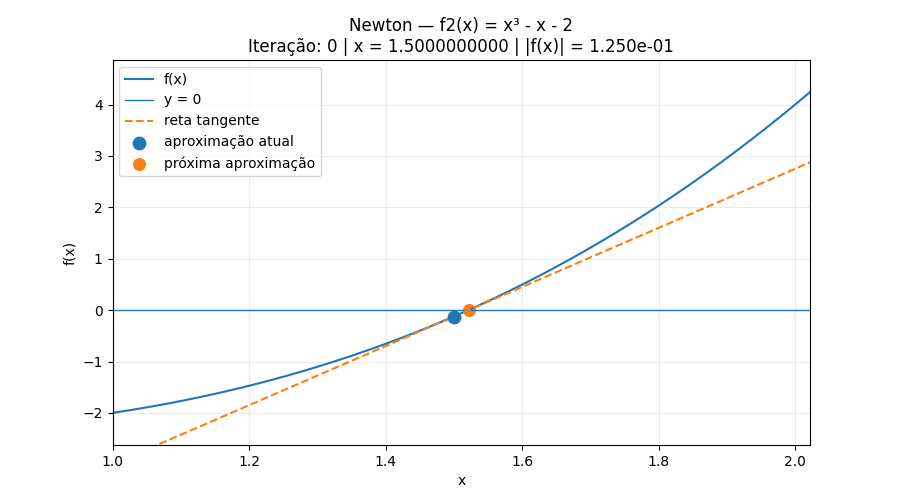

In [9]:
def animar_newton(nome_funcao, arquivo="newton.gif", intervalo_grafico=None):
    dados = funcoes[nome_funcao]
    f = dados["f"]
    df = dados["df"]
    x0 = dados["x0"]

    raiz, it, aprox, ok, hist = newton(f, df, x0)

    if intervalo_grafico is None:
        xmin = min(aprox) - 0.5
        xmax = max(aprox) + 0.5
    else:
        xmin, xmax = intervalo_grafico

    xs = np.linspace(xmin, xmax, 700)
    ys = [f(x) for x in xs]

    fig, ax = plt.subplots(figsize=(9, 5))

    def atualizar(frame):
        ax.clear()

        h = hist[frame]
        x = h["x"]
        fx = h["fx"]
        dfx = h["derivada"]

        ax.plot(xs, ys, label="f(x)")
        ax.axhline(0, linewidth=1, label="y = 0")

        # Tangente
        if abs(dfx) > EPS:
            xt = np.linspace(
                min(x - 1, xmin),
                max(x + 1, xmax),
                200
            )
            yt = fx + dfx * (xt - x)
            ax.plot(xt, yt, linestyle="--", label="reta tangente")

        ax.scatter([x], [fx], s=80, zorder=5,
                   label="aproximação atual")

        # Próximo ponto, quando existir
        if frame + 1 < len(hist):
            xn = hist[frame + 1]["x"]
            ax.scatter([xn], [0], s=70,
                       label="próxima aproximação")

        ax.set_title(
            f"Newton — {nome_funcao}\n"
            f"Iteração: {h['iteracao']} | "
            f"x = {x:.10f} | |f(x)| = {abs(fx):.3e}"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.grid(True, alpha=0.25)
        ax.legend()
        ax.set_xlim(xmin, xmax)

        ymin, ymax = min(ys), max(ys)
        margem_y = 0.10 * max(1, ymax - ymin)
        ax.set_ylim(ymin - margem_y, ymax + margem_y)

    anim = FuncAnimation(
        fig, atualizar, frames=len(hist),
        interval=900, repeat=False
    )

    anim.save(arquivo, writer=PillowWriter(fps=1.2))
    plt.close(fig)

    print(f"GIF salvo em: {arquivo}")
    print(f"Convergiu: {ok} | Iterações: {it}")

    return arquivo


# GIF 2
animar_newton(
    "f2(x) = x³ - x - 2",
    "02_newton_f2.gif"
)

display(Image(filename="02_newton_f2.gif"))

## 9. Animação — Secante

Para a secante, cada quadro mostra os dois pontos usados no passo e a reta que passa por eles. A interseção dessa reta com o eixo \(x\) fornece a nova aproximação.

GIF salvo em: 03_secante_f3.gif
Convergiu: True | Iterações: 5


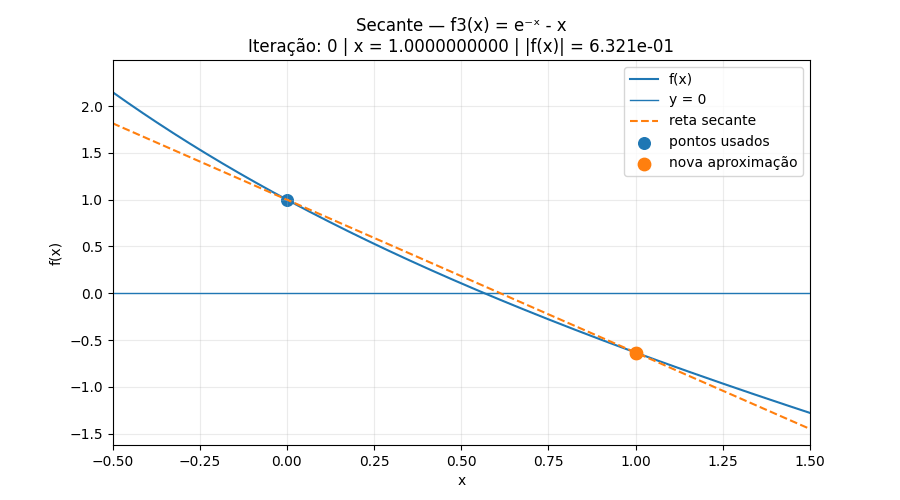

In [10]:
def animar_secante(nome_funcao, arquivo="secante.gif", intervalo_grafico=None):
    dados = funcoes[nome_funcao]
    f = dados["f"]

    raiz, it, aprox, ok, hist = secante(f, *dados["secante"])

    if intervalo_grafico is None:
        xmin = min(aprox) - 0.5
        xmax = max(aprox) + 0.5
    else:
        xmin, xmax = intervalo_grafico

    xs = np.linspace(xmin, xmax, 700)
    ys = [f(x) for x in xs]

    fig, ax = plt.subplots(figsize=(9, 5))

    def atualizar(frame):
        ax.clear()

        h = hist[frame]
        x0 = h["x0"]
        x1 = h["x1"]
        x2 = h["x"]
        fx2 = h["fx"]

        ax.plot(xs, ys, label="f(x)")
        ax.axhline(0, linewidth=1, label="y = 0")

        y0 = f(x0)
        y1 = f(x1)

        # Reta secante
        if abs(x1 - x0) > EPS:
            xt = np.linspace(
                min(x0, x1, x2) - 0.5,
                max(x0, x1, x2) + 0.5,
                200
            )
            m = (y1 - y0) / (x1 - x0)
            yt = y0 + m * (xt - x0)
            ax.plot(xt, yt, linestyle="--", label="reta secante")

        ax.scatter([x0, x1], [y0, y1], s=70,
                   label="pontos usados")

        ax.scatter([x2], [fx2], s=80, zorder=5,
                   label="nova aproximação")

        ax.set_title(
            f"Secante — {nome_funcao}\n"
            f"Iteração: {h['iteracao']} | "
            f"x = {x2:.10f} | |f(x)| = {abs(fx2):.3e}"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.grid(True, alpha=0.25)
        ax.legend()
        ax.set_xlim(xmin, xmax)

        ymin, ymax = min(ys), max(ys)
        margem_y = 0.10 * max(1, ymax - ymin)
        ax.set_ylim(ymin - margem_y, ymax + margem_y)

    anim = FuncAnimation(
        fig, atualizar, frames=len(hist),
        interval=900, repeat=False
    )

    anim.save(arquivo, writer=PillowWriter(fps=1.2))
    plt.close(fig)

    print(f"GIF salvo em: {arquivo}")
    print(f"Convergiu: {ok} | Iterações: {it}")

    return arquivo


# GIF 3
animar_secante(
    "f3(x) = e⁻ˣ - x",
    "03_secante_f3.gif"
)

display(Image(filename="03_secante_f3.gif"))

## 10. Gerar GIFs para todas as funções

A atividade exige pelo menos três combinações de função e método. As três células anteriores já atendem a esse requisito.

Se desejado, a célula abaixo gera GIFs para todas as 12 combinações.

In [11]:
# Opcional: gerar as 12 animações
gerar_todos = False

if gerar_todos:
    arquivos = []

    for i, nome in enumerate(funcoes.keys(), start=1):
        arquivo = animar_bissecao(
            nome,
            f"bissecao_{i}.gif"
        )
        arquivos.append(arquivo)

        arquivo = animar_newton(
            nome,
            f"newton_{i}.gif"
        )
        arquivos.append(arquivo)

        arquivo = animar_secante(
            nome,
            f"secante_{i}.gif"
        )
        arquivos.append(arquivo)

    print("Arquivos gerados:")
    for arquivo in arquivos:
        print("-", arquivo)

## 11. Salvando a tabela de resultados

A tabela pode ser exportada em CSV para ser utilizada no dashboard do Mathcha.

In [12]:
# Recupera a tabela sem a formatação textual, para manter os números como números
resultados_csv = []

for nome, dados in funcoes.items():
    f = dados["f"]
    df = dados["df"]

    for metodo in ["Bisseção", "Newton", "Secante"]:
        if metodo == "Bisseção":
            raiz, it, aprox, ok, hist = bissecao(f, *dados["intervalo"])
            valores = f"{dados['intervalo']}"
        elif metodo == "Newton":
            raiz, it, aprox, ok, hist = newton(f, df, dados["x0"])
            valores = f"x0 = {dados['x0']}"
        else:
            raiz, it, aprox, ok, hist = secante(f, *dados["secante"])
            valores = f"{dados['secante']}"

        resultados_csv.append({
            "Função": nome,
            "Método": metodo,
            "Valores iniciais": valores,
            "Raiz aproximada": raiz,
            "|f(x)| final": abs(f(raiz)),
            "Iterações": it,
            "Resultado": "Convergiu" if ok else "Falhou"
        })

tabela_csv = pd.DataFrame(resultados_csv)
tabela_csv.to_csv("tabela_resultados.csv", index=False, encoding="utf-8-sig")

print("Arquivo salvo: tabela_resultados.csv")
display(tabela_csv)

Arquivo salvo: tabela_resultados.csv


,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações,Resultado
0,f1(x) = x² - 2,Bisseção,"(1, 2)",1.414214,2.687177e-07,21,Convergiu
1,f1(x) = x² - 2,Newton,x0 = 1.5,1.414214,4.440892e-16,4,Convergiu
2,f1(x) = x² - 2,Secante,"(1, 2)",1.414214,8.881784e-16,6,Convergiu
3,f2(x) = x³ - x - 2,Bisseção,"(1, 2)",1.521380,1.449813e-08,22,Convergiu
4,f2(x) = x³ - x - 2,Newton,x0 = 1.5,1.521380,4.529710e-14,3,Convergiu
5,f2(x) = x³ - x - 2,Secante,"(1, 2)",1.521380,1.842970e-14,7,Convergiu
6,f3(x) = e⁻ˣ - x,Bisseção,"(0, 1)",0.567143,2.348157e-07,20,Convergiu
7,f3(x) = e⁻ˣ - x,Newton,x0 = 0.5,0.567143,4.440892e-15,3,Convergiu
8,f3(x) = e⁻ˣ - x,Secante,"(0, 1)",0.567143,1.242340e-13,5,Convergiu
9,f4(x) = x³ - 2x + 2,Bisseção,"(-2, -1)",-1.769292,2.550763e-09,21,Convergiu


## 12. Conclusão da atividade

Os três métodos foram implementados de forma independente e parametrizada, permitindo alterar a função, os valores iniciais, a tolerância e o número máximo de iterações sem modificar a estrutura dos algoritmos.

A bisseção utiliza um intervalo que contém uma mudança de sinal e apresenta convergência controlada pela redução sucessiva do intervalo. Newton utiliza a derivada da função e, quando parte de uma aproximação adequada, tende a apresentar convergência rápida. A secante evita a necessidade da derivada, utilizando dois pontos anteriores para construir uma reta secante.

As animações permitem visualizar graficamente a aproximação sucessiva das raízes, conforme solicitado na atividade.